In [ ]:
Bias variance trade-off , regularization, LASSO, Ridge, LASSO vs. Ridge, 
Elastic net, ploynomial regression

# The Bias-Variance Trade-off

The **Bias-Variance Trade-off** is one of the most fundamental concepts in machine learning. It describes the struggle to balance two distinct types of errors when training a model, with the ultimate goal of maximizing its ability to generalize well to unseen data.

---

## 1. Core Definitions

To understand the trade-off, we first need to break down the three components that make up a model's total error: **Bias**, **Variance**, and **Irreducible Error**.

* **What is Bias?**
    * Bias is the error introduced by approximating a real-world, highly complex problem with a much simpler model. 
    * *High Bias* means the model makes strong assumptions about the data, paying little attention to the training patterns.
    * **Result:** **Underfitting**. The model performs poorly on both the training data and new data.

* **What is Variance?**
    * Variance is the error introduced by the model's sensitivity to small fluctuations in the training dataset.
    * *High Variance* means the model pays *too much* attention to the training data, capturing the noise along with the underlying pattern.
    * **Result:** **Overfitting**. The model performs exceptionally well on training data but terribly on new, unseen data.

* **What is Irreducible Error?**
    * This is the noise inherent in the problem itself (e.g., missing variables, measurement errors). No matter how perfect your model is, you cannot eliminate this error.

---

## 2. The Mathematical Relationship

Mathematically, the expected prediction error of any machine learning model can be decomposed as follows:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

Your objective is to find the sweet spot where the sum of $\text{Bias}^2$ and $\text{Variance}$ is minimized. 

![Bias Variance Trade-off Curve](https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Bias_variance_tradeoff.svg/500px-Bias_variance_tradeoff.svg.png)

---

## 3. The Trade-Off Visualized (The Bullseye Analogy)

Think of the bias-variance trade-off as a game of darts, where the bullseye represents the true relationship in the data:

| | **Low Variance** | **High Variance** |
| :--- | :--- | :--- |
| **Low Bias** | **The Goal:** Darts are tightly clustered right in the bullseye. | Darts are spread out, but they are centered around the bullseye. |
| **High Bias** | Darts are tightly clustered, but far away from the bullseye. | Darts are both widely scattered and far off target. |

---

## 4. How Model Complexity Affects the Trade-off

As you change the complexity of a model, bias and variance move in opposite directions:

* **Low Complexity Models** *(e.g., Linear Regression, Logistic Regression)*
    * High Bias, Low Variance.
    * They are stable (low variance) but might miss complex patterns (high bias).
* **High Complexity Models** *(e.g., Deep Neural Networks, Decision Trees, KNN with $k=1$)*
    * Low Bias, High Variance.
    * They can fit complex shapes perfectly (low bias) but change drastically with different training data (high variance).

---

## 5. Summary: Diagnosing and Fixing the Issue

### High Bias (Underfitting)
* **Symptoms:** High training error and high testing error.
* **How to fix it:**
    * Increase model complexity (e.g., use a non-linear model, add more layers/neurons).
    * Add more features or perform feature engineering.
    * Decrease regularization constraints (e.g., lower L1/L2 penalties).

### High Variance (Overfitting)
* **Symptoms:** Very low training error but high testing error (a large gap between them).
* **How to fix it:**
    * Simplify the model or perform feature selection to reduce noise.
    * Add more training data (helps the model learn the true signal instead of noise).
    * Use **Regularization** techniques (Lasso, Ridge, Dropout).
    * Use **Ensemble Methods** (e.g., Random Forests use bagging to specifically reduce variance).

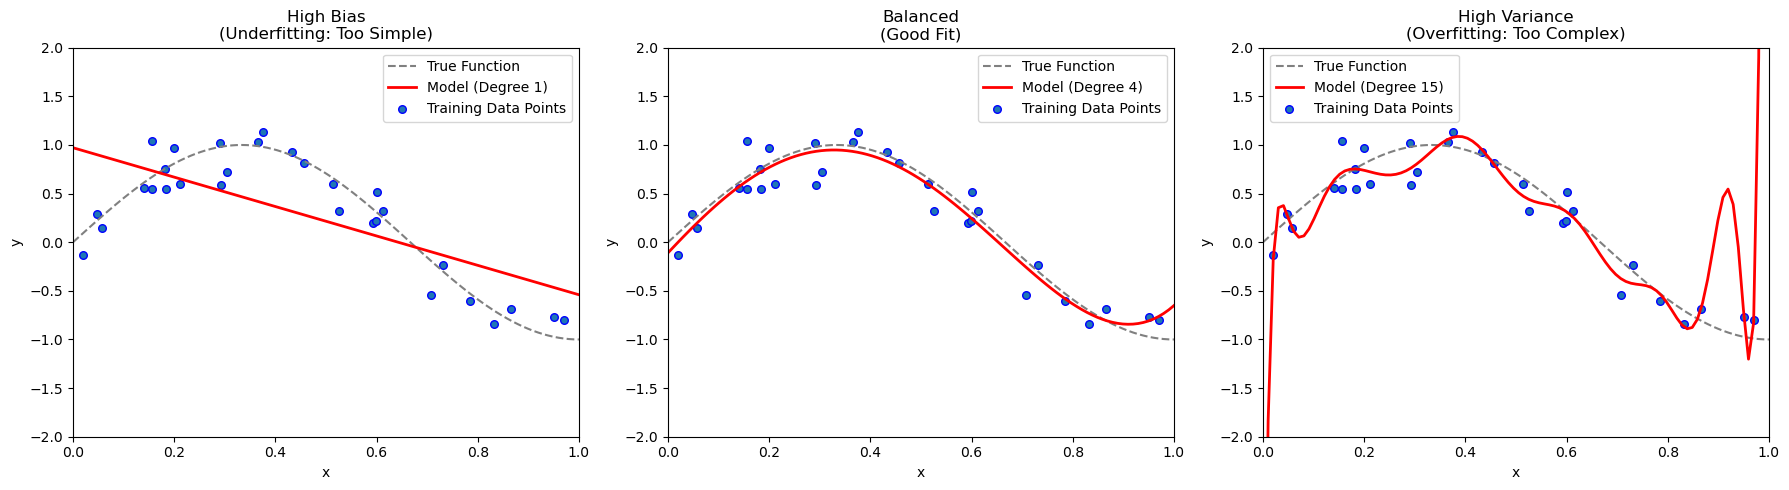

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Generate synthetic data with some random noise
np.random.seed(42)
def true_function(X):
    return np.sin(1.5 * np.pi * X)

# Training points
n_samples = 30
X_train = np.sort(np.random.rand(n_samples))
y_train = true_function(X_train) + np.random.randn(n_samples) * 0.2

# Testing points (to plot the smooth true function and model predictions)
X_test = np.linspace(0, 1, 100)

# 2. Define degrees for our polynomial models
# Degree 1 = High Bias, Low Variance (Underfitting)
# Degree 4 = Balanced Sweet Spot
# Degree 15 = Low Bias, High Variance (Overfitting)
degrees = [1, 4, 15]

plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    
    # Create and fit the polynomial model
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = make_pipeline(polynomial_features, linear_regression)
    pipeline.fit(X_train[:, np.newaxis], y_train)
    
    # Evaluate predictions
    y_pred = pipeline.predict(X_test[:, np.newaxis])
    
    # Plot results
    plt.plot(X_test, true_function(X_test), label="True Function", color="gray", linestyle="--")
    plt.plot(X_test, y_pred, label=f"Model (Degree {degree})", color="red", linewidth=2)
    plt.scatter(X_train, y_train, edgecolor='b', s=30, label="Training Data Points")
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    
    if degree == 1:
        plt.title("High Bias\n(Underfitting: Too Simple)")
    elif degree == 4:
        plt.title("Balanced\n(Good Fit)")
    else:
        plt.title("High Variance\n(Overfitting: Too Complex)")

plt.tight_layout()
plt.show()

# Regularization: Taming High Variance

Regularization prevents overfitting by penalizing the model for having large or overly complex coefficients (weights). Instead of letting the model perfectly fit every training data point, regularization forces the model to stay simpler and smoother, drastically improving its ability to generalize to new data.

---

## 1. How It Works Mathematically

In ordinary linear regression, the goal is to minimize the **Residual Sum of Squares (RSS)**:

$$\text{Loss} = \text{RSS}$$

When we apply regularization, we add a penalty term based on the size of the model's weights ($w$):

$$\text{Loss} = \text{RSS} + \alpha \cdot (\text{Penalty})$$

* $\alpha$ (Alpha/Lambda) is the **regularization strength hyperparameter**.
* If $\alpha = 0$, you are doing standard regression (no regularization).
* If $\alpha$ is too high, the penalty dominates, forcing weights toward zero, which leads to **underfitting (High Bias)**.

---

## 2. The Three Common Types of Regularization

### A. Ridge Regression ($L_2$ Regularization)
Ridge regression adds a penalty equal to the **square of the magnitude** of the coefficients.

$$\text{Loss} = \text{RSS} + \alpha \sum_{j=1}^{p} w_j^2$$

* **Behavior:** It shrinks all coefficients *close* to zero, but never exactly to zero.
* **Best use case:** Use this when you have many features, and most of them have small but useful effects on the output.

### B. Lasso Regression ($L_1$ Regularization)
Lasso (Least Absolute Shrinkage and Selection Operator) adds a penalty equal to the **absolute value of the magnitude** of the coefficients.

$$\text{Loss} = \text{RSS} + \alpha \sum_{j=1}^{p} |w_j|$$

* **Behavior:** It can shrink coefficients **exactly to zero**. This effectively removes less important features from the model entirely.
* **Best use case:** Use this when you have a massive number of features and suspect only a few of them actually matter (**Feature Selection**).

### C. Elastic Net
Elastic Net combines both $L_1$ and $L_2$ penalties into a single loss function.

$$\text{Loss} = \text{RSS} + \alpha_1 \sum_{j=1}^{p} |w_j| + \alpha_2 \sum_{j=1}^{p} w_j^2$$

* **Behavior:** It balances feature elimination (Lasso) and weight shrinking (Ridge).
* **Best use case:** Highly effective when multiple features are highly correlated with each other.

---

## 3. Summary of Geometric Differences



The reason Lasso ($L_1$) drops weights to zero while Ridge ($L_2$) doesn't comes down to geometry:
* **$L_1$ (Lasso)** forms a diamond-shaped constraint region. The optimization budget is highly likely to hit the sharp corners on an axis, setting a weight directly to 0.
* **$L_2$ (Ridge)** forms a circular constraint region. The optimization path smoothly kisses the edge of the circle, minimizing weights dynamically without zeroing them out completely.

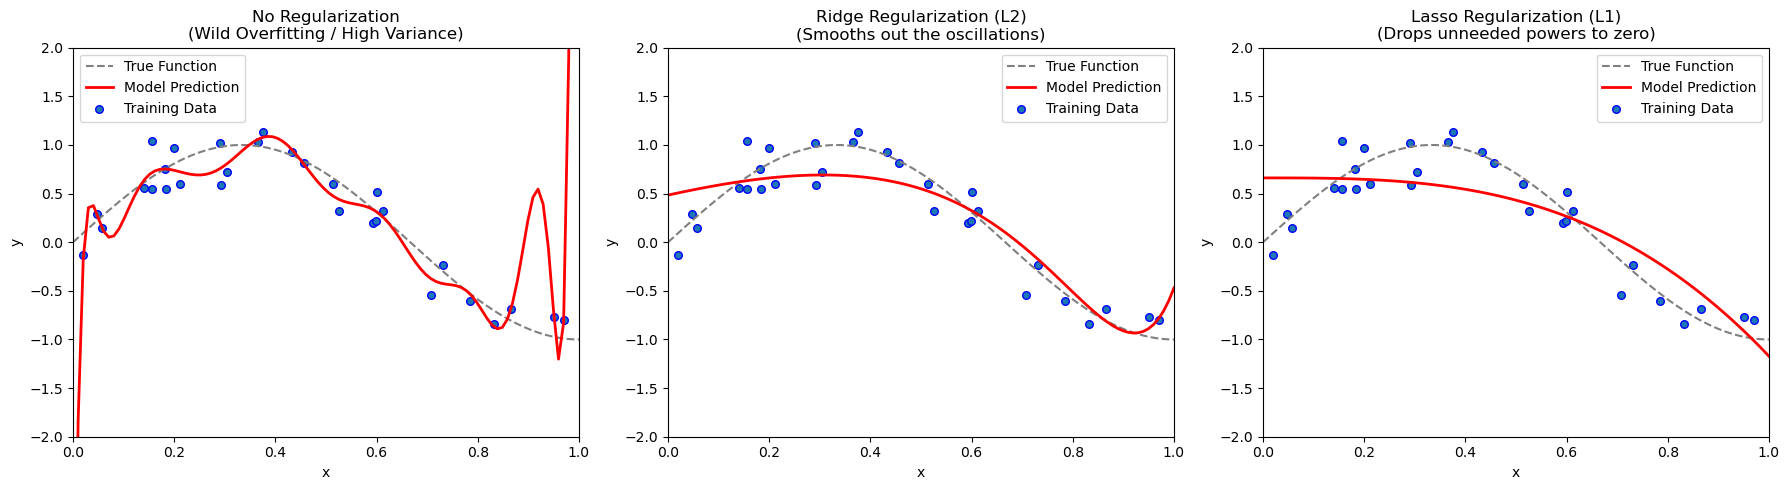

--- Coefficient Comparison (Truncated to first 5 polynomial terms) ---
Standard Regression Weights: [ 5.50809892e+02 -1.94500902e+04  3.60976822e+05 -4.09167341e+06
  3.09423419e+07]
Ridge (L2) Weights:         [ 1.14484504 -1.0096633  -1.30891833 -1.04158927 -0.681109  ]
Lasso (L1) Weights:         [ 0.         -0.         -1.83343443 -0.         -0.        ]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import warnings
warnings.filterwarnings('ignore') # Suppress small convergence warnings for clean output

# 1. Recreate the noisy synthetic sine wave data
np.random.seed(42)
def true_function(X):
    return np.sin(1.5 * np.pi * X)

n_samples = 30
X_train = np.sort(np.random.rand(n_samples))
y_train = true_function(X_train) + np.random.randn(n_samples) * 0.2
X_test = np.linspace(0, 1, 100)

# 2. Initialize 3 models, all using a complex 15th-degree polynomial
degree = 15
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Model A: Standard Linear Regression (No regularization -> Overfits)
model_none = make_pipeline(poly, LinearRegression())
model_none.fit(X_train[:, np.newaxis], y_train)

# Model B: Ridge Regression (L2 Penalty -> Shrinks weights smoothly)
# alpha=0.1 balances complexity and flatness
model_ridge = make_pipeline(poly, Ridge(alpha=0.1))
model_ridge.fit(X_train[:, np.newaxis], y_train)

# Model C: Lasso Regression (L1 Penalty -> Knocks weak weights to exactly 0)
# alpha=0.01 forces feature selection on unneeded polynomial powers
model_lasso = make_pipeline(poly, Lasso(alpha=0.01))
model_lasso.fit(X_train[:, np.newaxis], y_train)

# 3. Plotting the results
plt.figure(figsize=(18, 5))

models = [model_none, model_ridge, model_lasso]
titles = [
    "No Regularization\n(Wild Overfitting / High Variance)",
    "Ridge Regularization (L2)\n(Smooths out the oscillations)",
    "Lasso Regularization (L1)\n(Drops unneeded powers to zero)"
]

for i, (model, title) in enumerate(zip(models, titles)):
    plt.subplot(1, 3, i + 1)
    y_pred = model.predict(X_test[:, np.newaxis])
    
    plt.plot(X_test, true_function(X_test), label="True Function", color="gray", linestyle="--")
    plt.plot(X_test, y_pred, label="Model Prediction", color="red", linewidth=2)
    plt.scatter(X_train, y_train, edgecolor='b', s=30, label="Training Data")
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.title(title)
    plt.legend(loc="best")

plt.tight_layout()
plt.show()

# 4. Print the coefficients to see the difference mathematically
print("--- Coefficient Comparison (Truncated to first 5 polynomial terms) ---")
print(f"Standard Regression Weights: {model_none.named_steps['linearregression'].coef_[:5]}")
print(f"Ridge (L2) Weights:         {model_ridge.named_steps['ridge'].coef_[:5]}")
print(f"Lasso (L1) Weights:         {model_lasso.named_steps['lasso'].coef_[:5]}")

# LASSO Regression ($L_1$ Regularization)

**LASSO** stands for **Least Absolute Shrinkage and Selection Operator**. It is a powerful variation of linear regression used to prevent **High Variance (Overfitting)** by adding a penalty to the model's loss function. 

Its defining superpower is **automated feature selection**—it can completely eliminate unhelpful or redundant features from your model.

---

## 1. The Mathematics Behind LASSO

In ordinary least squares (OLS) linear regression, the model tries to minimize the **Residual Sum of Squares (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2$$

LASSO introduces an **$L_1$ penalty** to this equation, which is proportional to the **sum of the absolute values** of the coefficients ($\beta$):

$$\text{Loss}_{\text{LASSO}} = \text{RSS} + \alpha \sum_{j=1}^{p} |\beta_j|$$

* **$\alpha$ (Alpha/Lambda):** This is the regularization strength hyperparameter.
    * If $\alpha = 0$: The penalty has no effect, turning the model back into standard Linear Regression.
    * As $\alpha \to \infty$: The penalty dominates, forcing coefficients down toward zero. If alpha is too high, the model will **underfit**.

---

## 2. Core Mechanics: How LASSO Works

LASSO performs two critical tasks simultaneously:

### A. Shrinkage (Regularization)
It pulls the magnitude of all coefficient weights down. By restricting how large the weights can grow, it prevents the model from relying too heavily on any single feature or memorizing random noise in the training data.

### B. Selection (Sparsity)
Unlike Ridge regression, which only shrinks weights close to zero, LASSO's mathematical penalty forces less important coefficients **exactly to zero**. 

$$\beta_j = 0$$

When a coefficient becomes zero, that feature is completely removed from the mathematical equation. This creates a **sparse model**.

---

## 3. The Geometric Intuition: Why Weights Hit Zero

The reason LASSO can zero out coefficients comes down to geometry. 

When optimizing the model, we are trying to find where our standard error circles intersect with our allowed regularization "budget" boundary.



* The LASSO ($L_1$) constraint boundary forms a **sharp diamond** (in 2D space) or a polyhedron (in higher dimensions) because it uses absolute values ($|\beta_1| + |\beta_2| \leq t$).
* As the error ellipse expands outward from the center, it is geometrically highly probable to hit one of the **sharp corners** of the diamond first.
* Because these corners rest directly on the axes, hitting a corner means the coordinate for the other axis is forced **exactly to 0**.

---

## 4. Pros and Cons of LASSO

### Pros:
* **Feature Selection:** It automatically cleans up your dataset by discarding useless, noisy, or irrelevant features.
* **Interpretability:** Because it removes variables, the final model equation is simpler, smaller, and much easier to explain to stakeholders.
* **Memory Efficient:** Sparse models require fewer computational resources to store and deploy.

### Cons:
* **The Multicollinearity Problem:** If you have a group of highly correlated features (e.g., `room_count` and `square_footage`), LASSO will typically pick *one* of them arbitrarily and drop the rest to zero, losing potentially useful nuanced data.
* **Data Constraints:** If the number of features ($p$) is greater than the number of observations ($n$), LASSO will select at most $n$ features before it saturates.

---

## 5. When Should You Use LASSO?

You should reach for LASSO regression when:
1. You have a **high-dimensional dataset** (hundreds or thousands of features).
2. You suspect that only a **small fraction** of those features actually drive or influence the target variable.
3. You need a clean, sparse, and lightweight model for production.

# Ridge Regression ($L_2$ Regularization)

**Ridge Regression** is a variation of linear regression designed to combat **High Variance (Overfitting)**. When a standard regression model has too many features, or when those features are highly correlated, the model's weights (coefficients) can explode in size, making the model incredibly sensitive to minor fluctuations in the training data.

Ridge fixes this by adding a penalty to the loss function that forces the coefficients to stay small and controlled.

---

## 1. The Mathematics Behind Ridge

In ordinary least squares (OLS) linear regression, the model tries to minimize the **Residual Sum of Squares (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2$$

Ridge Regression introduces an **$L_2$ penalty** to this objective function, which is proportional to the **sum of the squared magnitudes** of the coefficients ($\beta$):

$$\text{Loss}_{\text{Ridge}} = \text{RSS} + \alpha \sum_{j=1}^{p} \beta_j^2$$

* **$\alpha$ (Alpha/Lambda):** This is the regularization strength hyperparameter.
    * If $\alpha = 0$: The penalty term is nullified, and the model behaves exactly like standard Linear Regression.
    * As $\alpha \to \infty$: The penalty dominates, forcing the coefficients closer and closer to zero, but never exactly to zero. If alpha is too high, the model will **underfit**.

---

## 2. Core Mechanics: How Ridge Works

### A. Proportional Shrinkage (The "Soft" Penalty)
Because Ridge squares the coefficients in its penalty term, it penalizes larger weights much more severely than smaller ones. As a result, it shrinks all weights down smoothly and proportionately. 

### B. Why Weights Never Hit Zero
Unlike LASSO ($L_1$), Ridge **never drops coefficients exactly to zero**. It smoothly dials down the influence of less important features, keeping them in the model with tiny weights. 

$$\beta_j \to 0 \quad (\text{but } \beta_j \neq 0)$$

Because all features are retained, Ridge always produces a **dense model**.

---

## 3. The Geometric Intuition: The Smooth Circle

The reason Ridge shrinks weights smoothly without zeroing them out comes down to geometry. 

When optimizing the model, we are trying to find where our standard error circles intersect with our allowed regularization "budget" boundary.



* The Ridge ($L_2$) constraint boundary forms a **perfectly smooth circle** (in 2D space) or a sphere (in higher dimensions) because it uses squared values ($\beta_1^2 + \beta_2^2 \leq t$).
* As the error ellipse expands outward from the center, it naturally "kisses" the smooth edge of the circle.
* Because a circle has no sharp corners resting on the axes, the point of intersection almost never lands exactly on an axis. Therefore, both weights retain some non-zero value.

---

## 4. Ridge's Secret Weapon: Handling Multicollinearity

One of Ridge's greatest strengths is how it handles **multicollinearity** (when features are highly correlated with each other, such as `house_size_sqft` and `number_of_rooms`). 

* **Standard Regression** gets confused by correlated features and might assign a massive positive weight to one and a massive negative weight to the other.
* **LASSO** will arbitrarily pick one feature, keep it, and drop the other to zero.
* **Ridge** handles this beautifully by **sharing the credit**. It groups correlated features together and distributes small, balanced weights across all of them, preserving the collective signal.

---

## 5. Pros and Cons of Ridge

### Pros:
* **Exceptional Stability:** Highly reliable when your dataset features high multicollinearity.
* **Prevents Exploding Weights:** Keeps coefficients small, ensuring that a tiny change in an input feature won't cause a wild, unpredictable swing in the prediction.
* **Mathematical Convenience:** The loss function is completely differentiable, meaning it has a closed-form analytical solution and trains very efficiently.

### Cons:
* **No Feature Selection:** It keeps every single feature in your model. If you feed it 1,000 features, your final equation will use 1,000 features, which can make the model harder to interpret.
* **Not Ideal for Sparsity:** If the true underlying relationship only relies on 2 or 3 key features out of hundreds, Ridge will struggle to find a clean solution compared to LASSO.

# LASSO vs. Ridge Regression

When a model suffers from **High Variance (Overfitting)**, it means it has memorized the noise in the training data instead of learning the underlying patterns. **Regularization** fixes this by adding a penalty term to the model's loss function, discouraging it from learning overly complex relationships.

The two most popular linear regularization techniques are **Ridge ($L_2$)** and **LASSO ($L_1$)**.

---

## 1. Ridge Regression ($L_2$ Regularization)

Ridge regression adds a penalty equal to the **sum of the squared magnitudes** of the coefficients.

### The Math
$$\text{Loss} = \text{Residual Sum of Squares (RSS)} + \alpha \sum_{j=1}^{p} w_j^2$$

* **$\alpha$ (Alpha):** Controls the regularization strength. As $\alpha \to \infty$, the coefficients approach zero.
* **Effect:** It shrinks all coefficients down **proportionately but smoothly**. 
* **Key Characteristic:** It **never** sets coefficients exactly to zero. All features are kept in the model, but their influence is heavily dialed down.

---

## 2. LASSO Regression ($L_1$ Regularization)

LASSO stands for *Least Absolute Shrinkage and Selection Operator*. It adds a penalty equal to the **sum of the absolute values** of the coefficients.

### The Math
$$\text{Loss} = \text{Residual Sum of Squares (RSS)} + \alpha \sum_{j=1}^{p} |w_j|$$

* **Effect:** It shrinks less important coefficients **all the way to exactly zero**.
* **Key Characteristic:** It acts as an automated **Feature Selection** mechanism. It drops useless or redundant variables from your equations entirely.

---

## 3. Direct Comparison: LASSO vs. Ridge

| Feature | Ridge Regression ($L_2$) | LASSO Regression ($L_1$) |
| :--- | :--- | :--- |
| **Penalty Type** | Squared weights ($\sum w^2$) | Absolute weights ($\sum \|w\|$) |
| **Feature Selection?** | ❌ No. Keeps all variables. |  Yes. Eliminates useless variables. |
| **Weights Configuration** | Shrinks weights smoothly/closely to 0. | Forces weights exactly to 0. |
| **Solution Stability** | Very stable with correlated features. | Can arbitrarily pick one feature over another if they correlate. |
| **Output Model** | Dense model (uses all features). | Sparse model (uses fewer features). |

---

## 4. The Geometry: Why LASSO drops weights to 0

The reason LASSO zeroes out coefficients while Ridge does not comes down to the mathematical geometry of their constraint boundaries:



* **Ridge ($L_2$) Penalty (Circle):** The constraint boundary is a smooth sphere/circle. When optimizing the loss function, the ellipse representing the original error smoothly "kisses" the circle. Because the circle has no sharp corners, the intersection point rarely lands exactly on an axis (where a weight would equal 0).
* **LASSO ($L_1$) Penalty (Diamond):** The constraint boundary forms a diamond/polyhedron with sharp corners. The error ellipse expanding outward is highly likely to hit one of these sharp corners resting directly on an axis. When it hits an axis corner, the coefficient for the opposing axis drops **exactly to zero**.

---

## 5. When to use which?

1. **Use Ridge Regression if:**
    * You have a massive number of features that all seem moderately important.
    * You have severe **multicollinearity** (features heavily correlated with each other). Ridge will distribute the weights across them smoothly rather than picking one at random.
2. **Use LASSO Regression if:**
    * You have hundreds of features, but you suspect only a small handful of them actually drive the target variable.
    * You need a highly interpretable, lightweight model that ignores unneeded features.
3. **Use Elastic Net (The Hybrid) if:**
    * You want the feature-dropping capabilities of LASSO but still need to handle correlated features safely like Ridge.

# Elastic Net Regression (The Hybrid Approach)

**Elastic Net** is a regularized regression method that mathematically combines both **LASSO ($L_1$)** and **Ridge ($L_2$)** penalties into a single loss function. 

While LASSO and Ridge are excellent tools on their own, they both have distinct flaws. Elastic Net was created to bridge the gap, taking the best characteristics of both worlds to handle complex, real-world datasets.

---

## 1. Why Do We Need Elastic Net? (The Flaws of $L_1$ and $L_2$)

To understand why Elastic Net is necessary, look at how LASSO and Ridge struggle in specific environments:

* **The LASSO Problem:** If you have a group of highly correlated features (e.g., `house_area_sqft` and `number_of_rooms`), LASSO will arbitrarily pick *one* feature to keep and drop the rest to zero. This can cause you to lose useful, nuanced information. Furthermore, if the number of features ($p$) is greater than the number of data samples ($n$), LASSO can select at most $n$ features before saturating.
* **The Ridge Problem:** Ridge retains all features. If you have 1,000 features, your model will include all 1,000. It cannot perform automated feature selection to give you a clean, interpretable, or lightweight model.

**Elastic Net solves this** by grouping correlated features together (like Ridge) while still maintaining the ability to completely zero out truly useless features (like LASSO).

---

## 2. The Mathematics Behind Elastic Net

Elastic Net minimizes a loss function that incorporates both the absolute magnitudes ($L_1$) and the squared magnitudes ($L_2$) of the coefficients ($\beta$):

$$\text{Loss}_{\text{ElasticNet}} = \text{RSS} + \alpha_1 \sum_{j=1}^{p} |\beta_j| + \alpha_2 \sum_{j=1}^{p} \beta_j^2$$

### The Modern Hyperparameter Implementation
In libraries like `scikit-learn`, the formula is often re-parameterized using two main knobs: `alpha` and `l1_ratio`.

* **`alpha`:** Controls the *total weight* of the regularization penalty.
* **`l1_ratio` (or $\rho$):** Controls the *mix* between LASSO and Ridge.
    * If `l1_ratio = 1`: The model becomes pure **LASSO Regression**.
    * If `l1_ratio = 0`: The model becomes pure **Ridge Regression**.
    * If `0 < l1_ratio < 1`: The model is a true **Elastic Net** hybrid.

---

## 3. The Geometric Intuition: The Soft Diamond



* **LASSO ($L_1$)** is a sharp diamond with pointed corners on the axes.
* **Ridge ($L_2$)** is a perfectly smooth circle.
* **Elastic Net** forms a geometric compromise: a **contoured, rounded diamond**. It retains the sharp corners on the axes (allowing weights to hit exactly zero for feature selection), but possesses a rounded body that prevents the model from making wild, arbitrary choices when features are highly correlated.

---

## 4. Pros and Cons of Elastic Net

### Pros:
* **Handles Multicollinearity Gracefully:** Unlike LASSO, if two variables are highly correlated, Elastic Net will form a "grouping effect" where they are either dropped together or kept together with shared weights.
* **No Feature Limits:** It can easily bypass the limitation where the number of features exceeds the number of samples ($p > n$).
* **Maximum Flexibility:** By tuning the `l1_ratio`, you can seamlessly sweep across the entire spectrum between Ridge and LASSO to find the perfect balance.

### Cons:
* **Computationally Expensive:** Because you now have two major hyperparameters to tune (`alpha` and `l1_ratio`), your cross-validation grid search takes longer and requires more computational power.

---

## 5. When Should You Use Elastic Net?

You should choose Elastic Net over standard LASSO or Ridge when:
1. You have a **high-dimensional dataset** where many features are highly correlated with each other.
2. You want the automated feature elimination of LASSO, but you don't want the model to make reckless, arbitrary choices when picking between correlated variables.
3. You are unsure whether $L_1$ or $L_2$ is fundamentally better suited for your data, allowing cross-validation to find the ideal mixture mathematically.

# Polynomial Regression

**Polynomial Regression** is a form of linear regression in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial. 

While it allows the model to fit complex, non-linear curves, it is a critical playground for understanding the **Bias-Variance Trade-off** and why **Regularization** becomes necessary.

---

## 1. Why Do We Need It? (The Limit of Lines)

Standard linear regression assumes a straight-line relationship:

$$y = \beta_0 + \beta_1 x$$

However, real-world data is rarely perfectly linear. If you try to fit a straight line to naturally curved data (like housing price trends over time, or car fuel efficiency vs. speed), your model will suffer from **High Bias (Underfitting)**. Polynomial regression solves this by introducing powers of $x$.

---

## 2. The Mathematics: Why is it still considered "Linear"?

A polynomial regression equation of degree $n$ looks like this:

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_n x^n + \epsilon$$

### The Mind-Bending Twist
Even though the graph of this equation is a curve, Polynomial Regression is still mathematically considered a **Linear Model**. 

Why? Because "linear" in statistics refers to the **coefficients ($\beta$)**, not the features ($x$). 
If we treat $x^2$ as a brand new feature called $z_1$, and $x^3$ as $z_2$, the equation transforms back into a standard, flat multi-linear regression equation:

$$y = \beta_0 + \beta_1 x + \beta_2 z_1 + \beta_3 z_2 + \dots$$

---

## 3. The Dangerous Trap: Overfitting and Complexity

Choosing the right polynomial degree ($n$) is a classic balancing act:

* **Degree 1 (Linear):** Flat line. Misses the curve entirely (**High Bias / Underfitting**).
* **Degree 2 or 3 (Quadratic/Cubic):** Smooth, elegant curve that captures the natural trend (**The Sweet Spot**).
* **Degree 15+:** A wild, zig-zagging line that aggressively forces itself to pass through every single training dot (**High Variance / Overfitting**). It learns the noise instead of the signal.



---

## 4. How to Implement It in Practice

Because polynomial regression is just linear regression with engineered features, workflows typically use a **two-step pipeline**:
1. **Transform:** Convert the single feature $x$ into multiple columns containing $x, x^2, x^3, \dots, x^n$.
2. **Fit:** Pass those new columns into a standard linear regression model.

### Crucial Best Practices
* **Feature Scaling:** Because squaring and cubing numbers makes them explode in size (e.g., $10^3 = 1000$), you **must** use a tool like `StandardScaler` before fitting your model. Otherwise, numerical instability will ruin your weights.
* **Combine with Regularization:** If you *must* use a high-degree polynomial to capture a complex shape, always anchor it down using **Ridge** or **LASSO** to prevent the edges from swinging wildly.

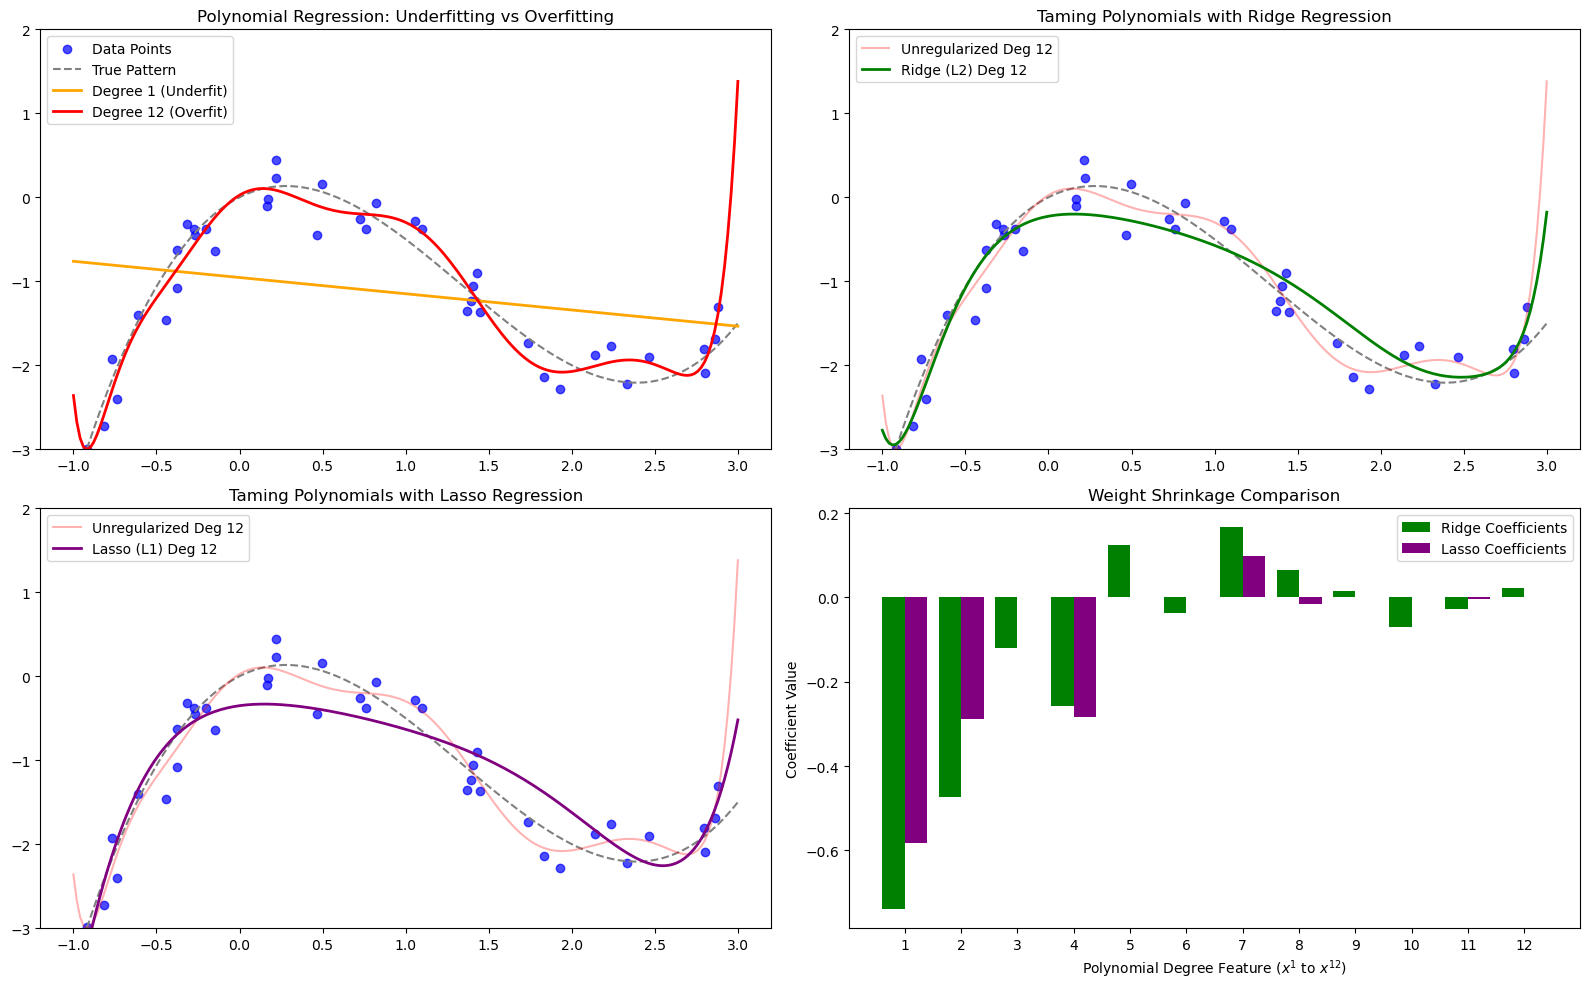

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 1. Generate curved synthetic data (a cubic relationship) with noise
np.random.seed(42)
def true_curve(X):
    return 0.5 * X**3 - 2 * X**2 + X

n_samples = 40
X = np.sort(np.random.uniform(-1, 3, n_samples))
# Add random noise
y = true_curve(X) + np.random.normal(0, 0.3, n_samples)

# Reshape for scikit-learn
X_plot = np.linspace(-1, 3, 200)[:, np.newaxis]
X_matrix = X[:, np.newaxis]

# 2. Setup the Plot
plt.figure(figsize=(16, 10))

# --- Plot 1: The Danger of High Degrees (Overfitting) ---
plt.subplot(2, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.7, label='Data Points')
plt.plot(X_plot, true_curve(X_plot), color='gray', linestyle='--', label='True Pattern')

# Simple Linear (Degree 1)
model_linear = make_pipeline(StandardScaler(), PolynomialFeatures(degree=1), LinearRegression())
model_linear.fit(X_matrix, y)
plt.plot(X_plot, model_linear.predict(X_plot), color='orange', linewidth=2, label='Degree 1 (Underfit)')

# Complex Polynomial (Degree 12)
model_poly = make_pipeline(StandardScaler(), PolynomialFeatures(degree=12), LinearRegression())
model_poly.fit(X_matrix, y)
plt.plot(X_plot, model_poly.predict(X_plot), color='red', linewidth=2, label='Degree 12 (Overfit)')

plt.title("Polynomial Regression: Underfitting vs Overfitting")
plt.ylim(-3, 2)
plt.legend()

# --- Plot 2: Fixing Overfitting with Ridge (L2) ---
plt.subplot(2, 2, 2)
plt.scatter(X, y, color='blue', alpha=0.7)
plt.plot(X_plot, true_curve(X_plot), color='gray', linestyle='--')
plt.plot(X_plot, model_poly.predict(X_plot), color='red', alpha=0.3, label='Unregularized Deg 12')

# Ridge Regularization on Degree 12
model_ridge = make_pipeline(StandardScaler(), PolynomialFeatures(degree=12), Ridge(alpha=2.0))
model_ridge.fit(X_matrix, y)
plt.plot(X_plot, model_ridge.predict(X_plot), color='green', linewidth=2, label='Ridge (L2) Deg 12')

plt.title("Taming Polynomials with Ridge Regression")
plt.ylim(-3, 2)
plt.legend()

# --- Plot 3: Fixing Overfitting with Lasso (L1) ---
plt.subplot(2, 2, 3)
plt.scatter(X, y, color='blue', alpha=0.7)
plt.plot(X_plot, true_curve(X_plot), color='gray', linestyle='--')
plt.plot(X_plot, model_poly.predict(X_plot), color='red', alpha=0.3, label='Unregularized Deg 12')

# Lasso Regularization on Degree 12
model_lasso = make_pipeline(StandardScaler(), PolynomialFeatures(degree=12), Lasso(alpha=0.05))
model_lasso.fit(X_matrix, y)
plt.plot(X_plot, model_lasso.predict(X_plot), color='purple', linewidth=2, label='Lasso (L1) Deg 12')

plt.title("Taming Polynomials with Lasso Regression")
plt.ylim(-3, 2)
plt.legend()

# --- Plot 4: Feature Selection Visualized (Coefficients) ---
plt.subplot(2, 2, 4)
# Extract coefficients from the linear models inside the pipelines
ridge_coefs = model_ridge.named_steps['ridge'].coef_[1:] # skip bias intercept
lasso_coefs = model_lasso.named_steps['lasso'].coef_[1:]

x_ticks = np.arange(1, 13)
plt.bar(x_ticks - 0.2, ridge_coefs, width=0.4, color='green', label='Ridge Coefficients')
plt.bar(x_ticks + 0.2, lasso_coefs, width=0.4, color='purple', label='Lasso Coefficients')
plt.xlabel("Polynomial Degree Feature ($x^1$ to $x^{12}$)")
plt.ylabel("Coefficient Value")
plt.title("Weight Shrinkage Comparison")
plt.xticks(x_ticks)
plt.legend()

plt.tight_layout()
plt.show()